# Nengo without the GUI
SYDE 556 — the same models from the GUI demo, run as scripts with **probes**.

The pattern is always: **build a `Network` → add `Probe`s → run a `Simulator` → plot `sim.data[probe]` against `sim.trange()`**.

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import nengo
from nengo.utils.ensemble import tuning_curves
from nengo.utils.matplotlib import rasterplot

%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 3.5)
print("nengo", nengo.__version__)

nengo 4.1.0


## 1. Computing a function (GUI tutorial 05), with probes
No slider here, so the input is a function of time. Probes record data; their `synapse` filters what is recorded.

In [20]:
model = nengo.Network(seed=1)
with model:
    stim = nengo.Node(lambda t: np.sin(2 * np.pi * t))
    a = nengo.Ensemble(n_neurons=50, dimensions=1)
    b = nengo.Ensemble(n_neurons=50, dimensions=1)
    nengo.Connection(stim, a)
    nengo.Connection(a, b, synapse=0.01, function=lambda x: x**2)

    p_stim = nengo.Probe(stim)
    p_a = nengo.Probe(a, synapse=0.01)          # decoded value of a
    p_b = nengo.Probe(b, synapse=0.01)          # decoded value of b
    p_spikes = nengo.Probe(a.neurons)           # raw spikes, unfiltered

with nengo.Simulator(model) as sim:
    sim.run(2.0)

t = sim.trange()

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

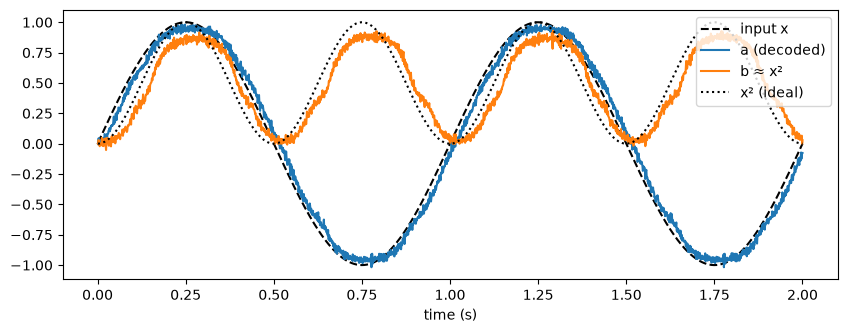

In [21]:
plt.plot(t, sim.data[p_stim], "k--", label="input x")
plt.plot(t, sim.data[p_a], label="a (decoded)")
plt.plot(t, sim.data[p_b], label="b ≈ x²")
plt.plot(t, sim.data[p_stim] ** 2, "k:", label="x² (ideal)")
plt.xlabel("time (s)"); plt.legend(loc="upper right"); plt.show()

## 2. Spikes
What the GUI's Spikes plot shows, but for the whole run. Sorting neurons doesn't matter for decoding; it's just display.

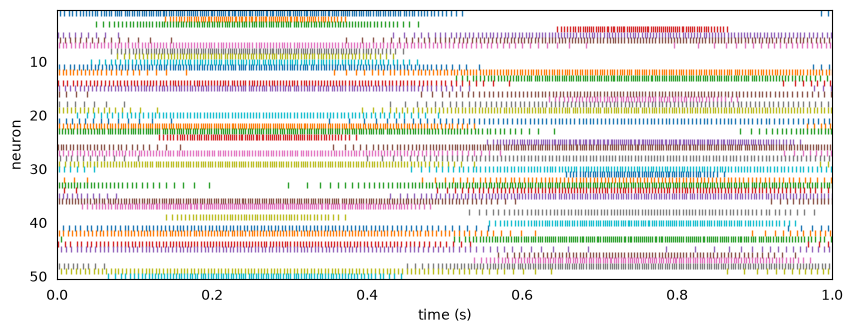

In [22]:
rasterplot(t, sim.data[p_spikes])
plt.xlim(0, 1); plt.xlabel("time (s)"); plt.ylabel("neuron"); plt.show()

## 3. Tuning curves
The same curves as **Details ...** in the GUI. Each neuron: an encoder (±1 in 1D), a gain and a bias → rate as a function of x.

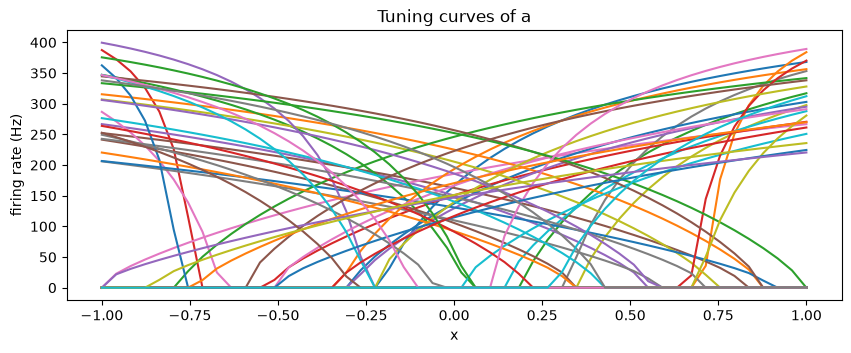

In [23]:
x, rates = tuning_curves(a, sim)
plt.plot(x, rates)
plt.xlabel("x"); plt.ylabel("firing rate (Hz)"); plt.title("Tuning curves of a"); plt.show()

## 4. Looking inside: encoders and decoders
Everything the builder computed lives in `sim.data`. To get decoders for a representation, make an explicit connection (probes on ensembles don't expose theirs).  
Principle 1, by hand: **x̂ = A · d**.

encoders: (50, 1)   gains: (50,)
decoders: (1, 50)


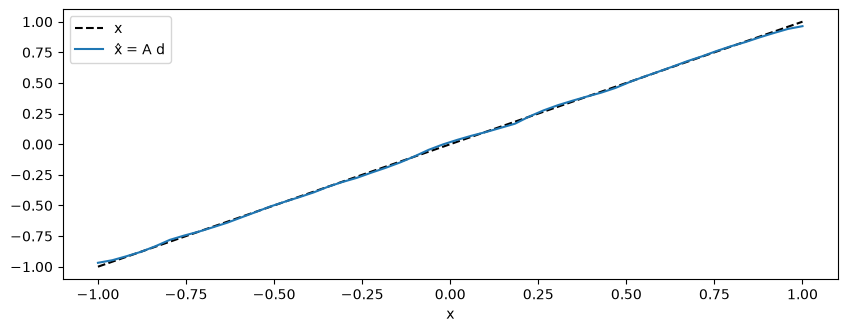

solver RMSE: [0.00941314]


In [24]:
with model:
    out = nengo.Node(size_in=1)
    conn = nengo.Connection(a, out)            # identity decoders for a

with nengo.Simulator(model, progress_bar=False) as sim:
    pass                                       # build only, no need to run

print("encoders:", sim.data[a].encoders.shape, "  gains:", sim.data[a].gain.shape)
d = sim.data[conn].weights                     # shape (1, n_neurons)
print("decoders:", d.shape)

x, A = tuning_curves(a, sim)                   # A: rates at each x
x_hat = A @ d.T
plt.plot(x, x, "k--", label="x")
plt.plot(x, x_hat, label="x̂ = A d")
plt.xlabel("x"); plt.legend(); plt.show()
print("solver RMSE:", sim.data[conn].solver_info["rmses"])

## 5. Multiplication (GUI tutorial 09)
Both values must be in one 2D population before the nonlinearity can be decoded. Radius 1.5 ≈ √2 covers the corner (1, 1).

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

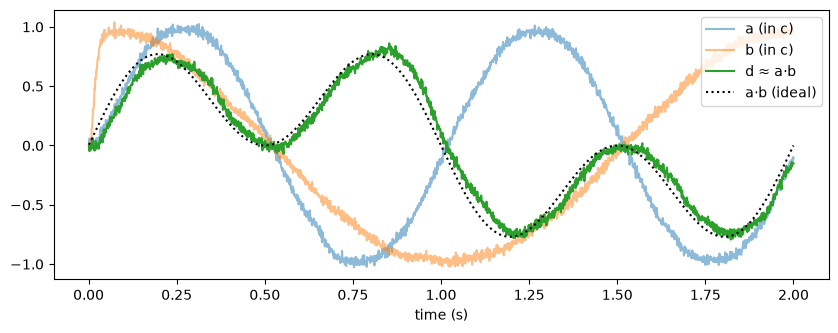

In [25]:
with nengo.Network(seed=2) as mult:
    stim_a = nengo.Node(lambda t: np.sin(2 * np.pi * t))
    stim_b = nengo.Node(lambda t: np.cos(np.pi * t))
    a = nengo.Ensemble(50, dimensions=1)
    b = nengo.Ensemble(50, dimensions=1)
    c = nengo.Ensemble(200, dimensions=2, radius=1.5)
    d = nengo.Ensemble(50, dimensions=1)
    nengo.Connection(stim_a, a)
    nengo.Connection(stim_b, b)
    nengo.Connection(a, c[0])
    nengo.Connection(b, c[1])
    nengo.Connection(c, d, function=lambda v: v[0] * v[1])

    p_ab = nengo.Probe(c, synapse=0.01)
    p_d = nengo.Probe(d, synapse=0.01)

with nengo.Simulator(mult) as sim:
    sim.run(2.0)

t = sim.trange()
ideal = np.sin(2 * np.pi * t) * np.cos(np.pi * t)
plt.plot(t, sim.data[p_ab], alpha=0.5, label=["a (in c)", "b (in c)"])
plt.plot(t, sim.data[p_d], label="d ≈ a·b")
plt.plot(t, ideal, "k:", label="a·b (ideal)")
plt.xlabel("time (s)"); plt.legend(loc="upper right"); plt.show()

## 6. Why scripts: parameter sweeps
Hard to do with sliders. Error vs. number of neurons, averaged over 5 seeds. `solver_info["rmses"]` is the static decoding error with noise-regularized decoders; no simulation needed, so this is fast.  
Small N: distortion dominates (∝ 1/N). Large N: the regularization (noise) term takes over (∝ 1/√N).

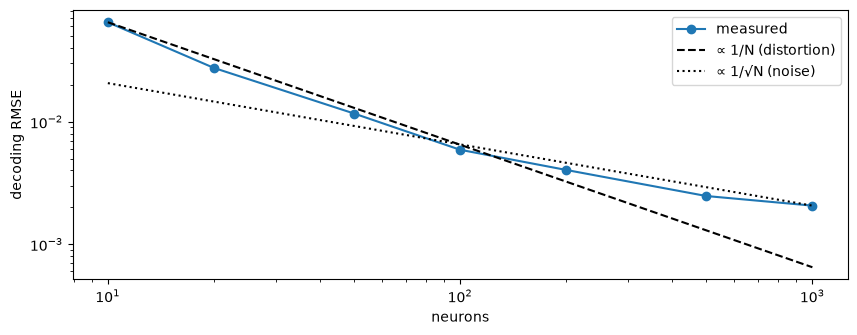

In [26]:
Ns = [10, 20, 50, 100, 200, 500, 1000]
seeds = range(5)
err = np.zeros((len(Ns), len(seeds)))

for i, n in enumerate(Ns):
    for j, s in enumerate(seeds):
        with nengo.Network(seed=s) as net:
            ens = nengo.Ensemble(n, dimensions=1)
            out = nengo.Node(size_in=1)
            cn = nengo.Connection(ens, out)
        with nengo.Simulator(net, progress_bar=False) as sim:
            err[i, j] = sim.data[cn].solver_info["rmses"][0]

plt.loglog(Ns, err.mean(axis=1), "o-", label="measured")
N = np.array(Ns)
plt.loglog(N, err.mean(axis=1)[0] * (N[0] / N), "k--", label="∝ 1/N (distortion)")
plt.loglog(N, err.mean(axis=1)[-1] * np.sqrt(N[-1] / N), "k:", label="∝ 1/√N (noise)")
plt.xlabel("neurons"); plt.ylabel("decoding RMSE"); plt.legend(); plt.show()

## 7. Teaser: memory (GUI tutorial 11)
A recurrent connection integrates its input. Why the two 0.1s have to match is Principle 3, coming soon.

In [ ]:
tau = 0.1
with nengo.Network(seed=3) as mem:
    stim = nengo.Node(nengo.processes.Piecewise({0: 0, 0.2: 1, 0.8: 0, 1.2: -1, 1.5: 0}))
    a = nengo.Ensemble(50, dimensions=1)
    b = nengo.Ensemble(100, dimensions=1)
    nengo.Connection(stim, a)
    nengo.Connection(a, b, transform=tau, synapse=tau)
    nengo.Connection(b, b, synapse=tau)

    p_in = nengo.Probe(stim)
    p_b = nengo.Probe(b, synapse=0.01)

with nengo.Simulator(mem) as sim:
    sim.run(2.0)

t = sim.trange()
plt.plot(t, sim.data[p_in], "k--", label="input")
plt.plot(t, sim.data[p_b], label="b (memory)")
plt.plot(t, np.cumsum(sim.data[p_in]) * sim.dt, "k:", label="∫ input (ideal)")
plt.xlabel("time (s)"); plt.legend(loc="upper right"); plt.show()

## Same file in the GUI and as a script
In a `.py` file, put the `Simulator` and plotting under `if __name__ == "__main__":`.  
`nengo myfile.py` then opens the model in the GUI, and `python myfile.py` runs it headless.